In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 150)

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style('whitegrid')
sns.set_palette('viridis')

pd.set_option('display.max_columns', None)

In [39]:
df = pd.read_csv(r"Data/bank-additional-full.csv", sep=";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Data Understanding

In [40]:
df.shape

(41188, 21)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [6]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

The dataset contains **41,188** records and **21** features, including both numerical and categorical variables. There are no actual NaN values, but missing information is encoded as the string **"unknown"** in several categorical features and should be identified and handled during data preprocessing.

# EDA

In [7]:
numerical_cols = df.select_dtypes(include= 'number').columns.tolist()
categorical_cols = df.drop(columns = ["y"]).select_dtypes(include= 'str').columns.tolist()

In [8]:
print("counts of numerical columns:", len(numerical_cols))
print(numerical_cols)
print("------------------------------------------------")
print("counts of categorical columns:", len(categorical_cols))
print(categorical_cols)

counts of numerical columns: 10
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
------------------------------------------------
counts of categorical columns: 10
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


### Target Distribution

     Counts    Percent
y                     
no    36548  88.734583
yes    4640  11.265417


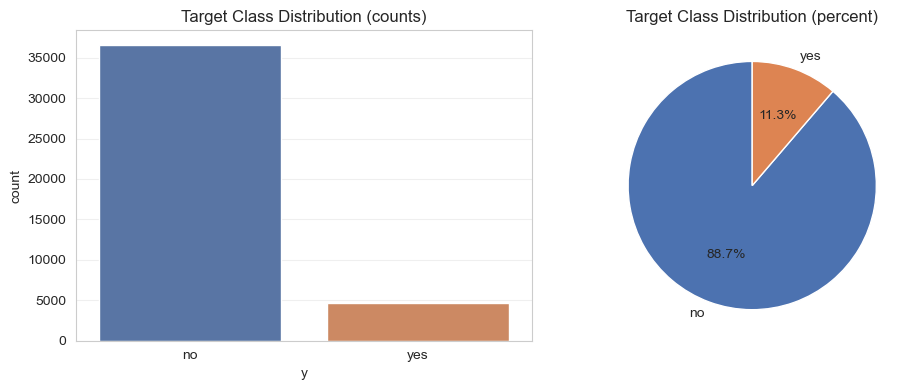

In [9]:
target_counts = df["y"].value_counts()
target_percent = df["y"].value_counts(normalize=True) * 100

target_table = pd.DataFrame({"Counts": target_counts,
                            "Percent": target_percent})
print(target_table)

fig , ax = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(x=df["y"], data=df, ax=ax[0], palette=['#4C72B0', '#DD8452'])
ax[0].set_title("Target Class Distribution (counts)")

ax[1].pie(target_counts, labels=target_counts.index, autopct='%1.1f%%',
          colors=['#4C72B0', '#DD8452'], startangle=90)
ax[1].set_title("Target Class Distribution (percent)")
plt.tight_layout()
plt.show()

The target variable is **highly imbalanced**, with approximately **88.7%** of observations belonging to the "no" class and only **11.3%** to the "yes" class (roughly an 8:1 ratio).

### Numerical Columns

In [10]:
df[numerical_cols].describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


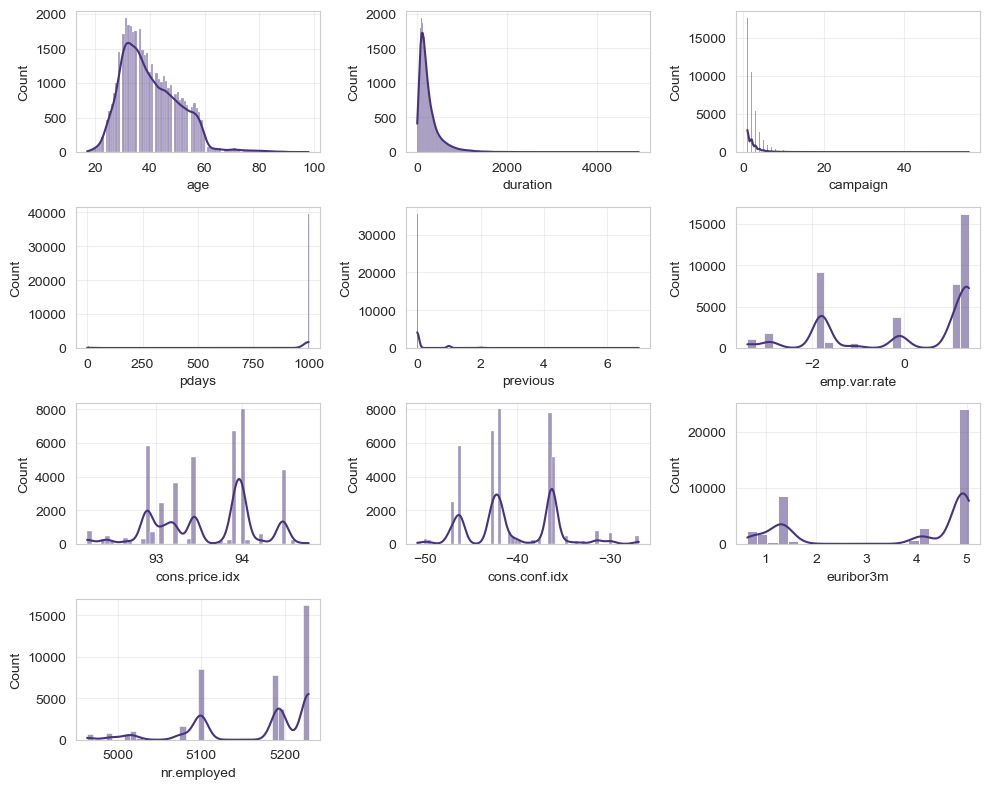

In [11]:
plt.figure(figsize = (10,8))
for idx,cols in enumerate(numerical_cols, start = 1):
    plt.subplot(4,3,idx)
    sns.histplot(df[cols], kde = True)

plt.tight_layout()
plt.show()

- **age** shows a roughly normal distribution with slight positive skewness. 
- **duration, campaign**, and **previous** are highly right-skewed, indicating the presence of outliers. 
- **pdays** is dominated by the sentinel value 999, resulting in a distorted distribution. 
- **Macroeconomic variables** exhibit multimodal patterns due to repeated time-based observations rather than continuous measurements.

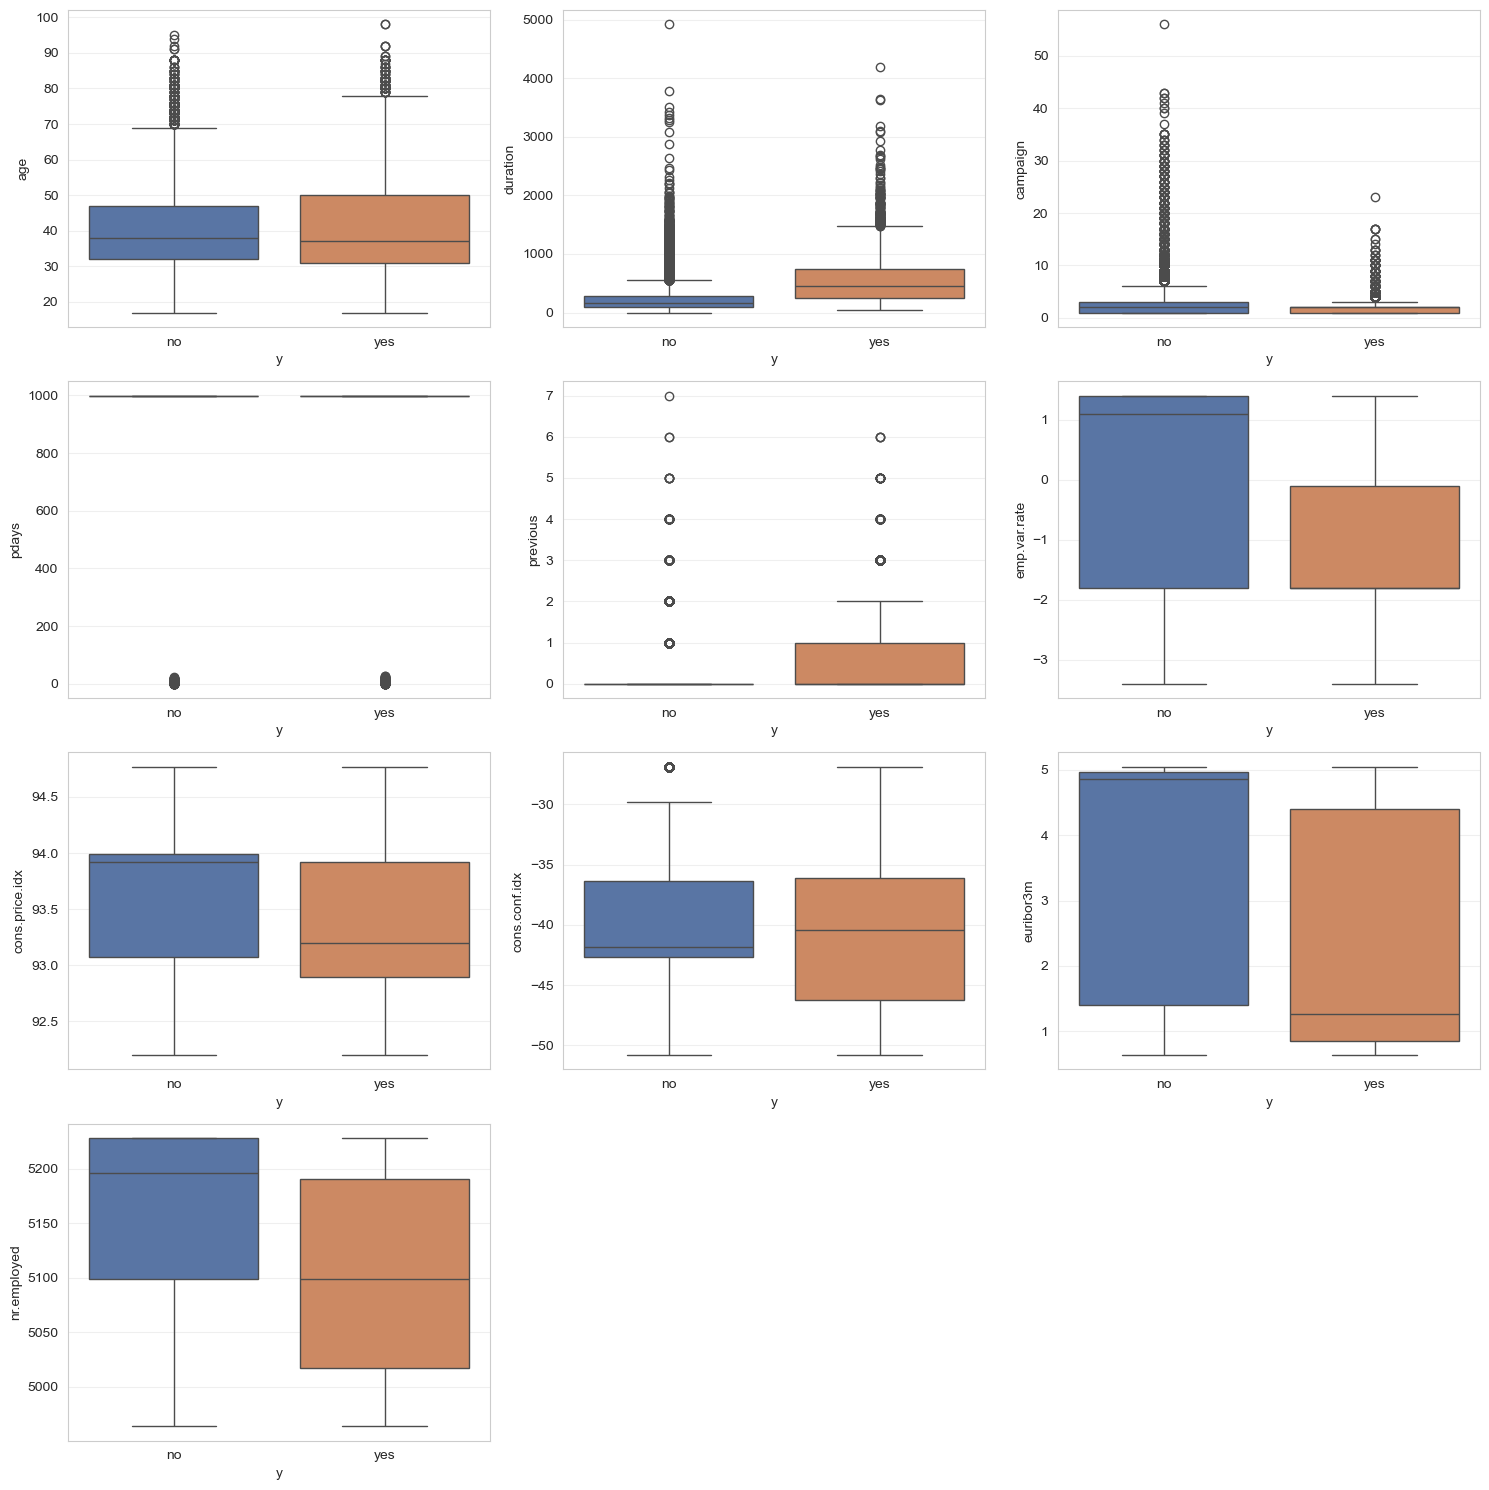

In [12]:
plt.figure(figsize = (15,15))
for i, col in enumerate(numerical_cols, start = 1):
    plt.subplot(4,3,i)
    sns.boxplot(x=df["y"], y=col, data=df, palette=['#4C72B0', '#DD8452'])
plt.tight_layout()
plt.show()

- **Duration:** Strongest predictor of subscription; however, it introduces **data leakage** since it is only known after the call.
- **Age:** Weak overall effect, with slightly higher subscription rates among very young and older customers.
- **Campaign:** Customers contacted fewer times are more likely to subscribe, while repeated calls reduce conversion.
- **Pdays & Previous:** Customers with successful previous campaign interactions have a higher probability of subscription.
- **Economic Indicators:** Lower **euribor3m**, **emp.var.rate**, and **nr.employed** are associated with higher subscription rates, indicating increased demand for secure savings during weaker economic conditions.

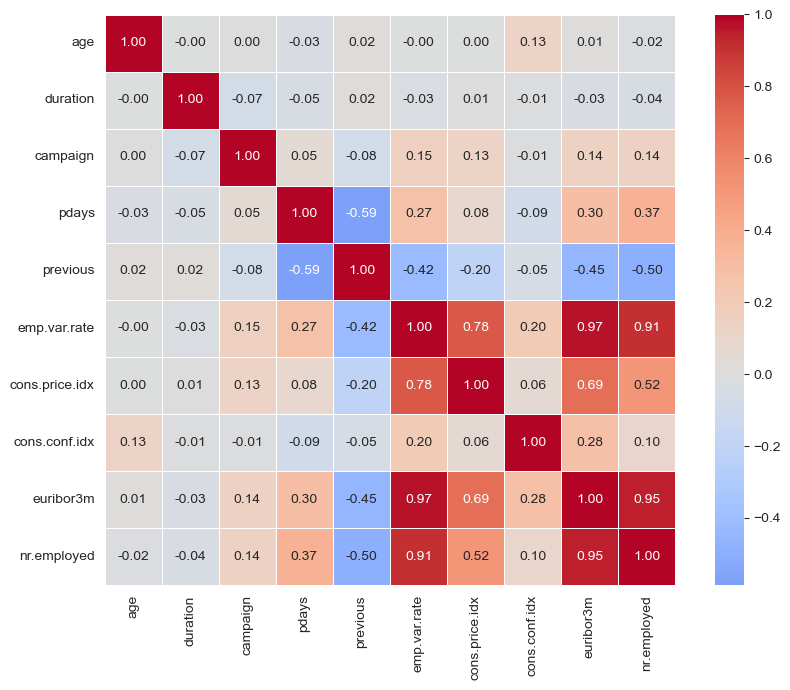

In [13]:
corr = df[numerical_cols].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.tight_layout()
plt.show()

A **strong positive correlation** was observed among **emp.var.rate, euribor3m,** and **nr.employed**, indicating that these macroeconomic indicators capture similar economic conditions. This suggests the presence of multicollinearity, which can lead to unstable coefficient estimates in linear models such as Logistic Regression. However, this issue generally has a much smaller impact on tree-based models such as Random Forest and XGBoost.

### Categorical Columns

In [14]:
df[categorical_cols].describe(include = "all")

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563


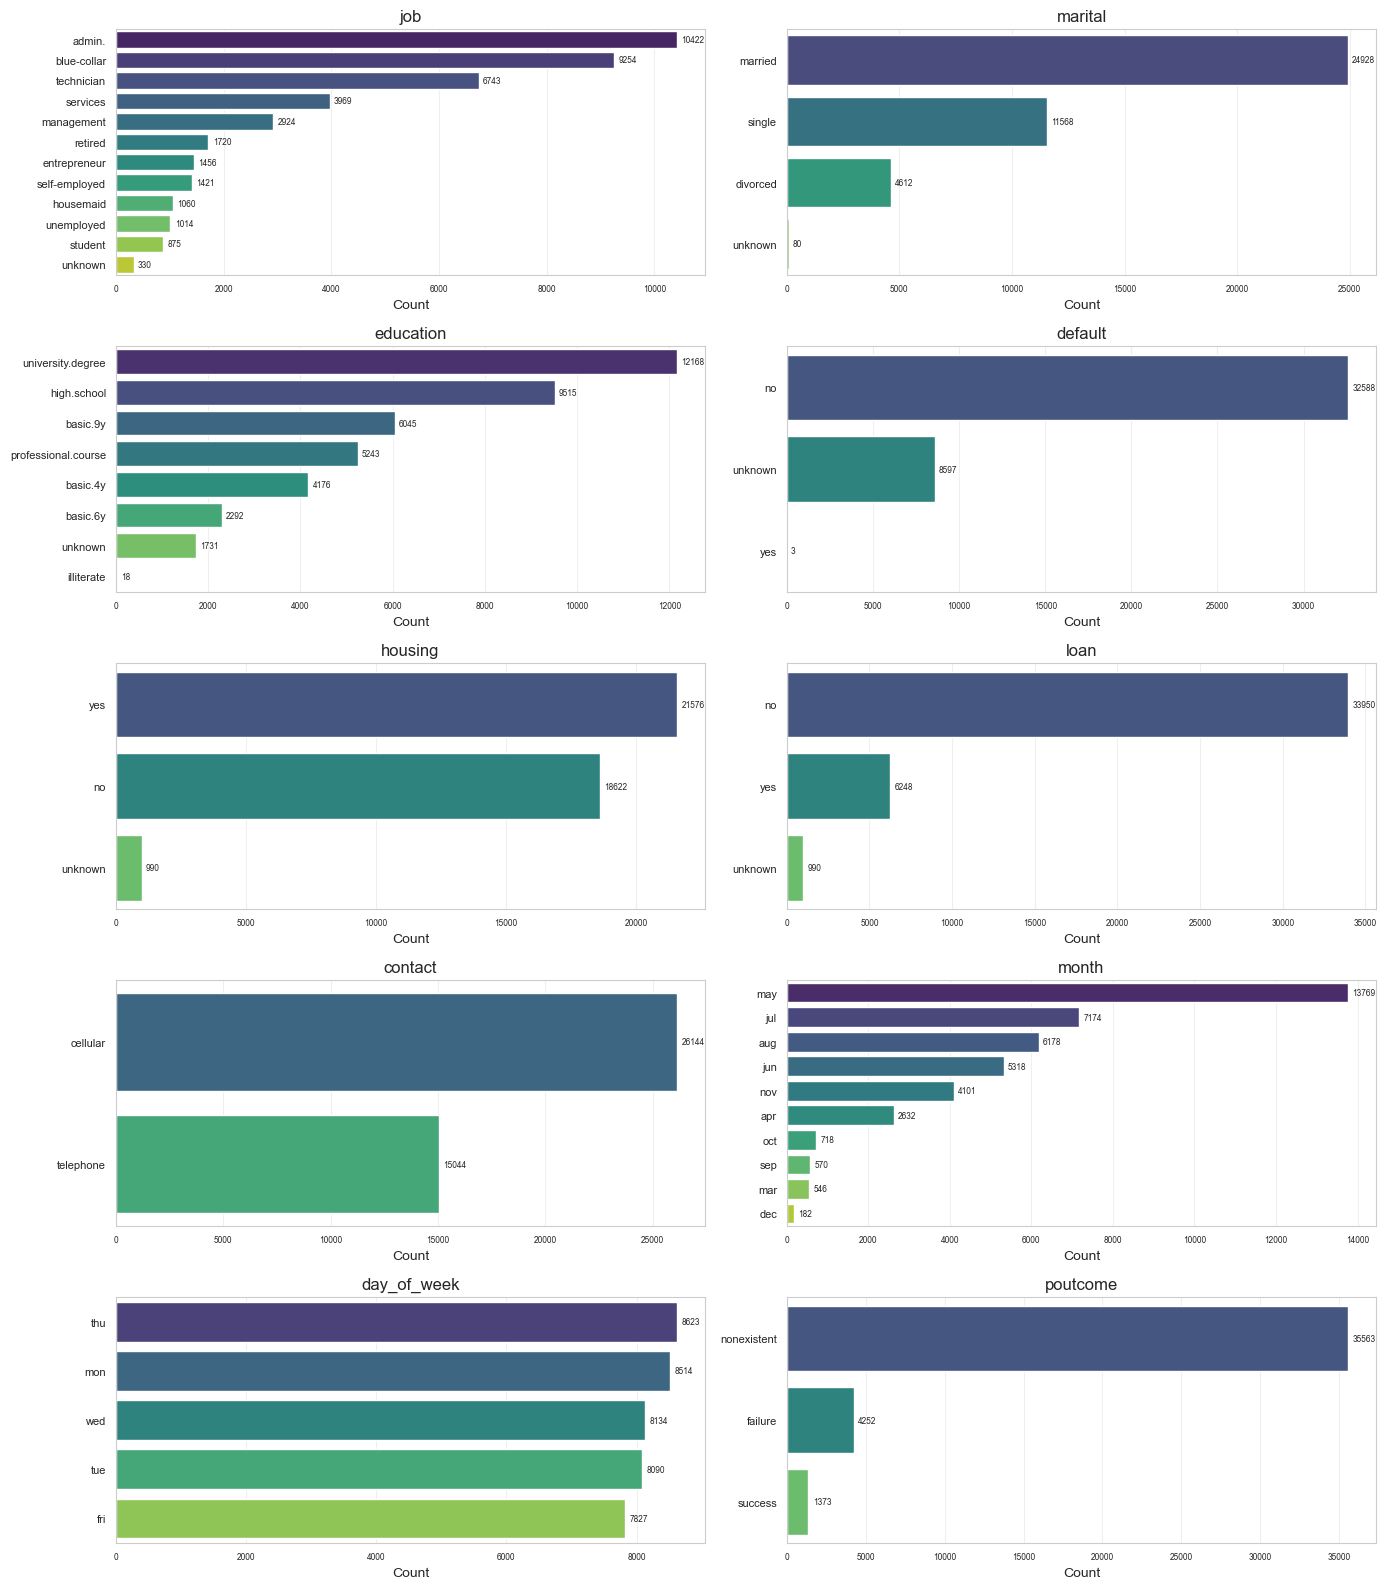

In [15]:
plt.figure(figsize=(14,16))
for idx, col in enumerate(categorical_cols, start=1):
    plt.subplot(5, 2, idx)

    counts = df[col].value_counts()

    ax = sns.barplot(
        x=counts.values,
        y=counts.index,
        palette='viridis'
    )

    ax.tick_params(axis='y', labelsize=8)
    ax.tick_params(axis='x', labelsize=6)
    ax.set_title(col, fontsize=12)
    ax.set_xlabel("Count")
    ax.set_ylabel("")
    for container in ax.containers:
        ax.bar_label(container, padding=3, fontsize=6)
plt.tight_layout()
plt.show()

- **admin** and **blue-collar** are the most common occupations in the dataset. 
- Most customers are **married**, and the dominant education levels are **university**.
- **degree** and **high.school** Customer contacts were primarily conducted via cellular, with the highest contact volumes occurring in **May, July**, and **August**. 
- Additionally, the majority of customers have **poutcome = nonexistent**, indicating that they had no outcome from a previous marketing campaign.

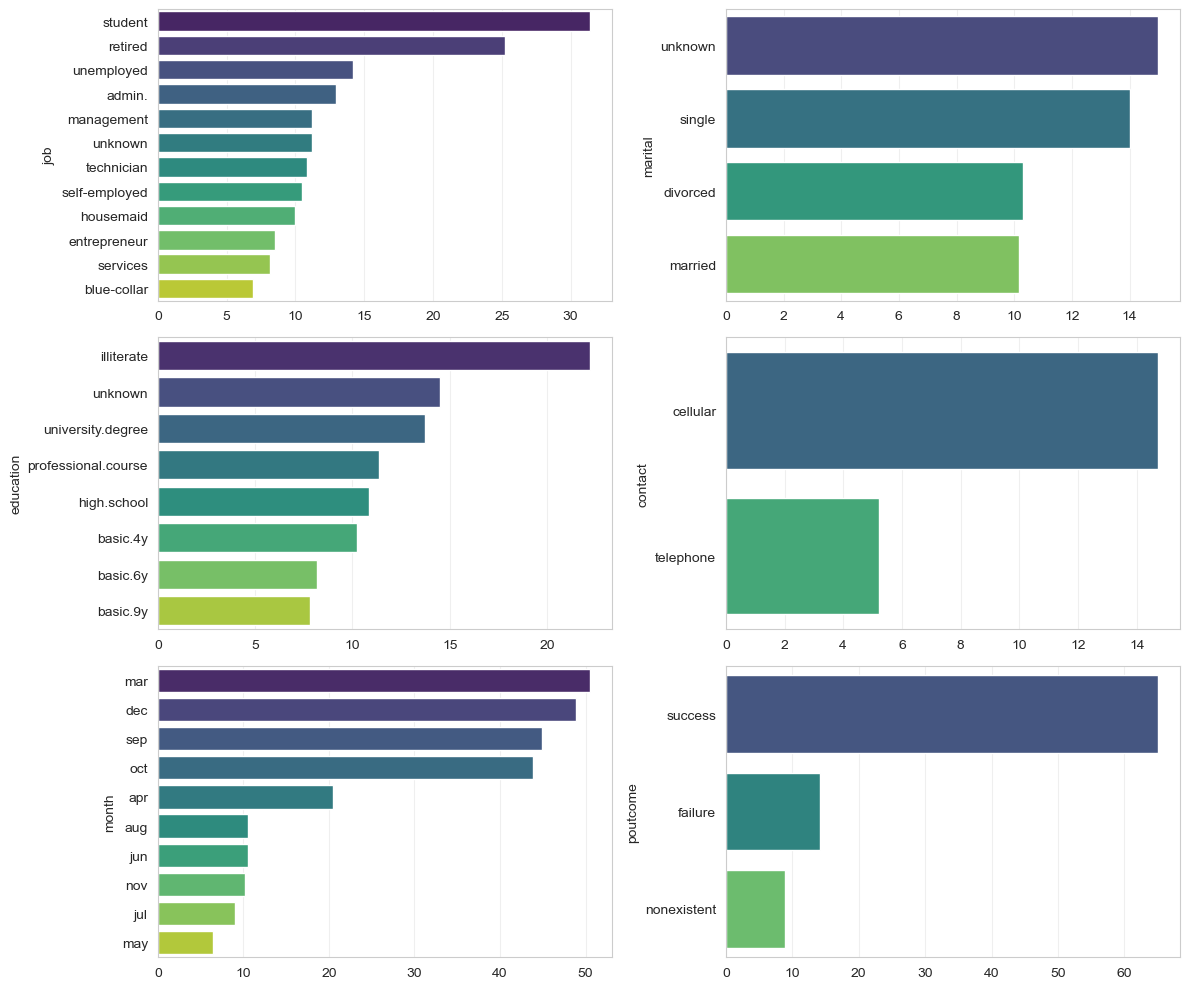

In [16]:
key_cats = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']

plt.figure(figsize = (12,10))
for idx,col in enumerate(key_cats, start = 1):
    plt.subplot(3,2,idx)
    rate = df.groupby(col)["y"].apply(lambda s: (s == 'yes').mean() * 100).sort_values(ascending=False)
    sns.barplot(x=rate.values, y=rate.index, palette='viridis')
plt.tight_layout()
plt.show()

### **Conversion Rate by Categorical Features**
- **job:** Students and retirees have the highest conversion rates, while blue-collar workers and entrepreneurs show the lowest.
- **education:** Customers with a university.degree generally exhibit higher conversion rates; the high rate for illiterate should be interpreted cautiously due to its very small sample size.
- **contact:** cellular contacts achieve substantially higher conversion rates than telephone.
- **month:** Conversion rates are highest in March, September, October, and December, while May has the lowest, suggesting a seasonal effect.
- **poutcome:** Customers with a previous campaign outcome of success have by far the highest probability of subscribing, making it one of the strongest predictive features.

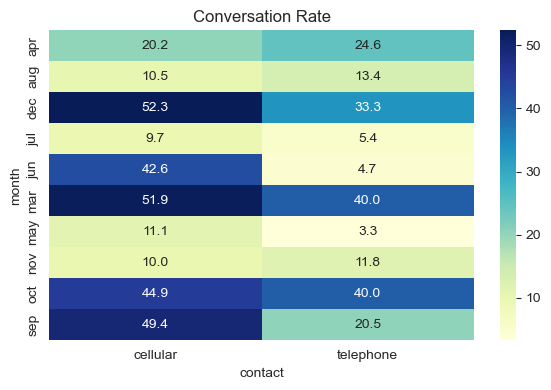

contact,cellular,telephone
month,,
apr,20.163599,24.598930
aug,10.475546,13.382900
dec,52.348993,33.333333
jul,9.694882,5.380334
jun,42.560976,4.668742
mar,51.851852,40.000000
may,11.127220,3.296570
nov,9.956474,11.764706
oct,44.937833,40.000000


In [17]:
pivot = df.pivot_table(index='month', columns='contact', values= 'y',
                        aggfunc=lambda s: (s == 'yes').mean() * 100)
plt.figure(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Conversation Rate')
plt.tight_layout()
plt.show()
pivot

A new feature, **month_contact**, was created to capture the interaction between the campaign month and the communication channel (month × contact). This feature enables the model to identify patterns that may not be captured when these variables are considered independently.

# Data Cleaning

In [18]:
df_clean = df.copy()

df_clean = df_clean.drop_duplicates().reset_index(drop=True)
df_clean.shape

(41176, 21)

### Handling Hidden Missing Values ("Unknown")

In [19]:
unknown_counts = {}
for c in df:
    cnt = (df[c] == 'unknown').sum()
    if cnt > 0:
        unknown_counts[c] = (cnt, round(cnt / len(df) * 100, 2))
unknown_df = pd.DataFrame(unknown_counts, index=['count', 'percent']).T.sort_values('count', ascending=False)
unknown_df

,count,percent
default,8597.0,20.87
education,1731.0,4.20
housing,990.0,2.40
loan,990.0,2.40
job,330.0,0.80
marital,80.0,0.19


The **"unknown" category** will be retained as a distinct class rather than being removed or replaced through imputation. This approach will preserve the dataset size while allowing the model to leverage the potential predictive information contained in missing or undisclosed customer responses.

### Outlier Handling

In [20]:
cap_value = df_clean['campaign'].quantile(0.99)
n_capped = (df_clean['campaign'] > cap_value).sum()
df_clean['campaign'] = np.where(df_clean['campaign'] > cap_value, cap_value, df_clean['campaign'])
print(f"Campaign cap value (99th percentile): {cap_value}")
print(f"Number of capped records: {n_capped}")

Campaign cap value (99th percentile): 14.0
Number of capped records: 406


**Outlier treatment** was applied only to the campaign feature by capping values at the 99th percentile (Winsorization). This variable contained a small number of extreme observations that could disproportionately influence model training. Other features, such as age, were left unchanged because their values fell within realistic ranges and represented genuine customer characteristics rather than data errors. The duration feature was also left untouched at this stage, as its treatment (removal due to data leakage) was addressed separately during the feature engineering phase.

### Data Type Conversion

In [21]:
for c in categorical_cols:
    df_clean[c] = df_clean[c].astype('category')

df_clean["y"] = df_clean["y"].astype('category')

## Feature Engineering

In [22]:
df_feat = df_clean.copy()
df_feat = df_feat.drop(columns=['duration'])

The **duration feature** was **removed** because it is only known after the phone call has ended. Including this variable would introduce **data leakage**, leading to overly optimistic model performance. Since the objective is to predict customer subscription before making the call, duration is excluded to ensure the model reflects a realistic deployment scenario.

#### Handling Sentinel Values

In [23]:
df_feat['was_contacted_before'] = (df_feat['pdays'] != 999).astype(int)
df_feat['pdays_clean'] = np.where(df_feat['pdays'] == 999, 0, df_feat['pdays'] + 1)

df_feat = df_feat.drop(columns=['pdays'])
print(df_feat[['was_contacted_before', 'pdays_clean']].describe())

       was_contacted_before   pdays_clean
count          41176.000000  41176.000000
mean               0.036793      0.258087
std                0.188256      1.510540
min                0.000000      0.000000
25%                0.000000      0.000000
50%                0.000000      0.000000
75%                0.000000      0.000000
max                1.000000     28.000000


#### Binning Age

In [24]:
bins = [17, 25, 35, 45, 55, 65, 100]
labels = ['17-25', '26-35', '36-45', '46-55', '56-65', '65+']
df_feat['age_group'] = pd.cut(df_feat['age'], bins=bins, labels=labels, include_lowest=True)
print(df_feat['age_group'].value_counts().sort_index())

age_group
17-25     1665
26-35    14844
36-45    12839
46-55     8247
56-65     2963
65+        618
Name: count, dtype: int64


#### Interaction Feature

In [25]:
df_feat['month_contact'] = (df_feat['month'].astype(str) + '_' + df_feat['contact'].astype(str)).astype('category')
print(df_feat['month_contact'].value_counts())

month_contact
may_telephone    8250
jul_cellular     6092
aug_cellular     5907
may_cellular     5517
jun_telephone    4498
nov_cellular     3675
apr_cellular     2444
jul_telephone    1077
jun_cellular      820
oct_cellular      563
mar_cellular      486
sep_cellular      482
nov_telephone     425
aug_telephone     269
apr_telephone     187
oct_telephone     154
dec_cellular      149
sep_telephone      88
mar_telephone      60
dec_telephone      33
Name: count, dtype: int64


#### Log Transform

In [26]:
df_feat['campaign'] = np.log1p(df_feat['campaign'])

In [27]:
df_feat.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,was_contacted_before,pdays_clean,age_group,month_contact
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,0.693147,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,0,56-65,may_telephone
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,0.693147,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,0,56-65,may_telephone
2,37,services,married,high.school,no,yes,no,telephone,may,mon,0.693147,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,0,36-45,may_telephone
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,0.693147,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,0,36-45,may_telephone
4,56,services,married,high.school,no,no,yes,telephone,may,mon,0.693147,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0,0,56-65,may_telephone


In [28]:
df_feat.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'previous', 'poutcome',
       'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'was_contacted_before', 'pdays_clean', 'age_group',
       'month_contact'],
      dtype='str')

## Feature Selection Analysis

Before model training, seven feature selection techniques are applied to evaluate the importance of each feature. Since each method measures feature relevance from a different perspective, comparing their results provides a more comprehensive understanding of the dataset before building predictive models.

1. Correlation Analysis
2. Mutual Information

3. Chi-Square Test

4. ANOVA F-test

5. L1 Regularization (Lasso)

6. Recursive Feature Elimination (RFE)

7. Permutation Importance

In [29]:
from sklearn.preprocessing import LabelEncoder
df_fs = df_feat.copy()

cat_cols_fs = df_fs.drop(columns = ["y"]).select_dtypes(include = ["category", "object"]).columns.to_list()
num_cols_fs = df_fs.drop(columns = ["y"]).select_dtypes(include = ['int64', 'float64']).columns.to_list()

df_fs_encoded = df_fs.copy()
for c in cat_cols_fs:
    df_fs_encoded[c] = LabelEncoder().fit_transform(df_fs_encoded[c].astype(str))

y_fs = LabelEncoder().fit_transform(df_fs_encoded["y"].astype(str))
x_fs = df_fs_encoded.drop(columns = ["y"])

print(x_fs.shape)
print(y_fs.shape)

(41176, 22)
(41176,)


#### Correlation Analysis

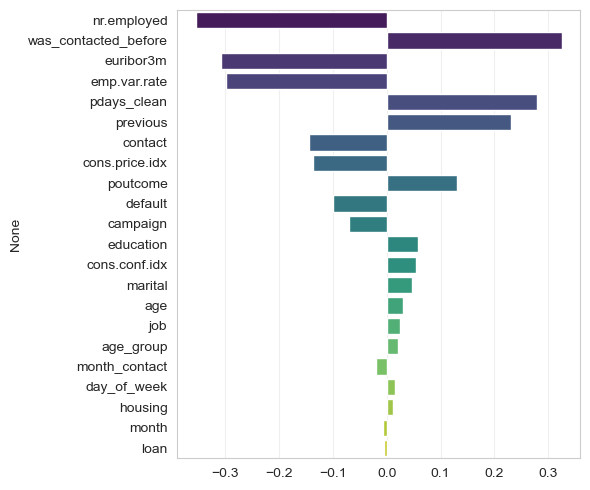

nr.employed            -0.354669
was_contacted_before    0.324910
euribor3m              -0.307740
emp.var.rate           -0.298289
pdays_clean             0.279053
previous                0.230202
contact                -0.144774
cons.price.idx         -0.136134
poutcome                0.129810
default                -0.099364
campaign               -0.070654
education               0.057776
cons.conf.idx           0.054802
marital                 0.046249
age                     0.030381
job                     0.025248
age_group               0.021045
month_contact          -0.020392
day_of_week             0.015970
housing                 0.011613
month                  -0.006051
loan                   -0.004922
Name: y, dtype: float64

In [30]:
corr_target = x_fs.assign(y = y_fs).corr()["y"].drop("y").sort_values(key=abs, ascending = False)
plt.figure(figsize=(6, 5))
sns.barplot(x=corr_target.values, y=corr_target.index, palette='viridis')
plt.title('')
plt.xlabel('')
plt.tight_layout()
plt.show()
corr_target

**Correlation analysis** showed that the most influential variables were **nr.employed, was_contacted_before, euribor3m, emp.var.rate**, and **pdays_clean**, indicating strong linear relationships with the target variable. 
    However, several variables such as **loan, housing, month**, and **day_of_week** exhibited very weak linear correlations.

#### Mutual Information

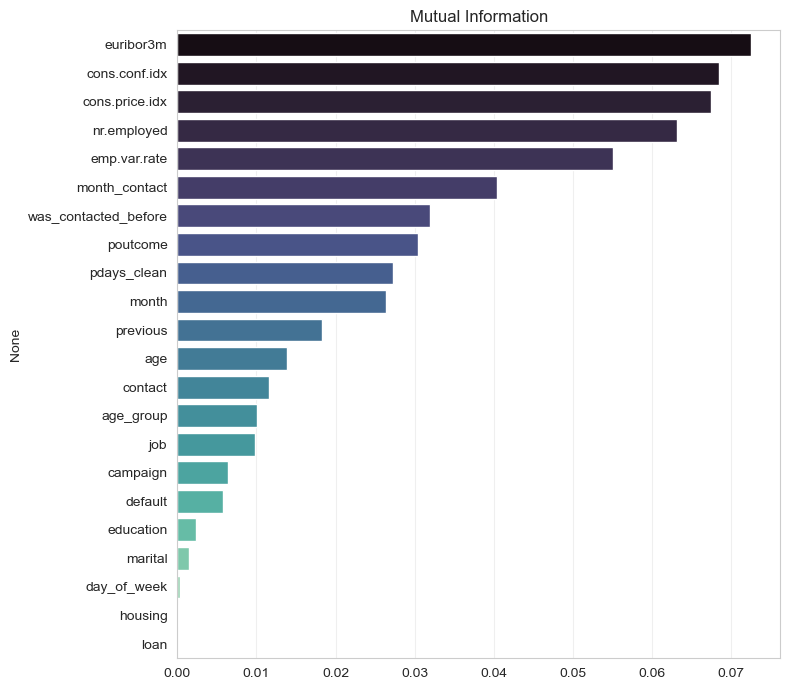

euribor3m               0.072529
cons.conf.idx           0.068407
cons.price.idx          0.067458
nr.employed             0.063167
emp.var.rate            0.055018
month_contact           0.040444
was_contacted_before    0.031962
poutcome                0.030391
pdays_clean             0.027210
month                   0.026428
previous                0.018303
age                     0.013837
contact                 0.011646
age_group               0.010069
job                     0.009864
campaign                0.006411
default                 0.005776
education               0.002387
marital                 0.001438
day_of_week             0.000321
housing                 0.000070
loan                    0.000013
dtype: float64

In [31]:
from sklearn.feature_selection import mutual_info_classif, chi2, f_classif, SelectKBest

mi_scores = mutual_info_classif(x_fs, y_fs, discrete_features=[c in cat_cols_fs for c in x_fs.columns],
                                  random_state=42)
mi_series = pd.Series(mi_scores, index=x_fs.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 7))
sns.barplot(x=mi_series.values, y=mi_series.index, palette='mako')
plt.title('Mutual Information')
plt.tight_layout()
plt.show()
mi_series

**Mutual Information** revealed that the economic indicators contained the highest amount of predictive information about customer subscription. Unlike correlation, Mutual Information also captured non-linear relationships, highlighting variables such as month_contact and month that showed relatively low linear correlation but still carried useful predictive information.

#### Chi-Square Test

In [32]:
x_fs_cat_only = x_fs[cat_cols_fs]
chi_scores, chi_pvalues = chi2(x_fs_cat_only, y_fs)
chi_result = pd.DataFrame({'feature': cat_cols_fs, 'chi2_score': chi_scores, 'p_value': chi_pvalues})
chi_result = chi_result.sort_values('chi2_score', ascending=False)
chi_result

,feature,chi2_score,p_value
6,contact,547.778461,3.830600e-121
3,default,321.891101,5.610249e-72
2,education,167.446537,2.672345e-38
9,poutcome,98.263330,3.662864e-23
0,job,91.060686,1.393327e-21
11,month_contact,44.603446,2.412667e-11
1,marital,27.844478,1.314688e-07
10,age_group,10.698659,1.072132e-03
8,day_of_week,10.233627,1.379032e-03
4,housing,5.030015,2.491168e-02


for categorical variables, the **Chi-Square test** identified **contact, default, education, poutcome, job**, and **month_contact** as statistically significant predictors of the target variable. In contrast, variables such as loan and month did not show significant statistical association, suggesting limited standalone predictive power.

#### ANOVA F-test

In [33]:
x_fs_num_only = x_fs[num_cols_fs]
f_scores, f_pvalues = f_classif(x_fs_num_only, y_fs)
anova_result = pd.DataFrame({'feature': num_cols_fs, 'f_score': f_scores, 'p_value': f_pvalues})
anova_result = anova_result.sort_values('f_score', ascending=False)
anova_result

,feature,f_score,p_value
7,nr.employed,5924.529145,0.000000e+00
8,was_contacted_before,4859.600544,0.000000e+00
6,euribor3m,4307.264549,0.000000e+00
3,emp.var.rate,4021.298297,0.000000e+00
9,pdays_clean,3477.010326,0.000000e+00
2,previous,2304.020429,0.000000e+00
4,cons.price.idx,777.463752,1.622226e-169
1,campaign,206.574117,9.966905e-47
5,cons.conf.idx,124.027852,9.132176e-29
0,age,38.037762,7.003244e-10


The **ANOVA analysis** confirmed that several numerical variables, particularly **nr.employed, was_contacted_before, euribor3m, emp.var.rate**, and **pdays_clean**, exhibited highly significant differences between the target classes. These variables demonstrated strong discriminative capability and were therefore considered important candidates for predictive modeling.

#### L1 Regularization (Lasso)

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

x_fs_scaled = StandardScaler().fit_transform(x_fs)
l1_model = LogisticRegression(penalty='l1', solver='liblinear', C=0.1,
                                class_weight='balanced', random_state=42, max_iter=1000)
l1_model.fit(x_fs_scaled, y_fs)
l1_coef = pd.Series(l1_model.coef_[0], index=x_fs.columns).sort_values(key=abs, ascending=False)

print(l1_coef)

emp.var.rate           -1.464419
euribor3m               1.078336
nr.employed            -0.707670
cons.price.idx          0.509523
contact                -0.335894
month_contact          -0.251535
was_contacted_before    0.205303
poutcome                0.155006
age                     0.121731
age_group              -0.097719
default                -0.095916
cons.conf.idx           0.061881
marital                 0.058529
education               0.055340
day_of_week             0.053463
campaign               -0.047694
previous               -0.046453
housing                -0.017788
loan                   -0.011678
job                     0.009100
month                   0.000000
pdays_clean             0.000000
dtype: float64


**L1 regularization** performed embedded feature selection by shrinking unimportant coefficients toward zero. The model completely eliminated **month** and **pdays_clean**, indicating that these variables provided little additional information after considering the remaining features. The largest coefficients were assigned to emp.var.rate, euribor3m, nr.employed, and cons.price.idx, emphasizing their importance in the Logistic Regression model.

#### Recursive Feature Elimination (RFE)

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE

rfe_estimator = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42,
                                          class_weight='balanced', n_jobs=-1)
rfe = RFE(estimator=rfe_estimator, n_features_to_select=10, step=2)
rfe.fit(x_fs, y_fs)
rfe_result = pd.DataFrame({'feature': x_fs.columns, 'selected': rfe.support_, 'rank': rfe.ranking_})
rfe_result = rfe_result.sort_values('rank')
rfe_result

,feature,selected,rank
0,age,True,1
13,emp.var.rate,True,1
14,cons.price.idx,True,1
15,cons.conf.idx,True,1
12,poutcome,True,1
18,was_contacted_before,True,1
17,nr.employed,True,1
16,euribor3m,True,1
19,pdays_clean,True,1
21,month_contact,True,1


**Random Forest Feature Importance** highlighted **euribor3m, nr.employed, emp.var.rate**, and **cons.conf.idx** as the most influential variables for reducing impurity within decision trees. Unlike linear methods, Random Forest also assigned noticeable importance to variables with non-linear effects, demonstrating its ability to capture complex feature interactions.

#### Permutation Importance

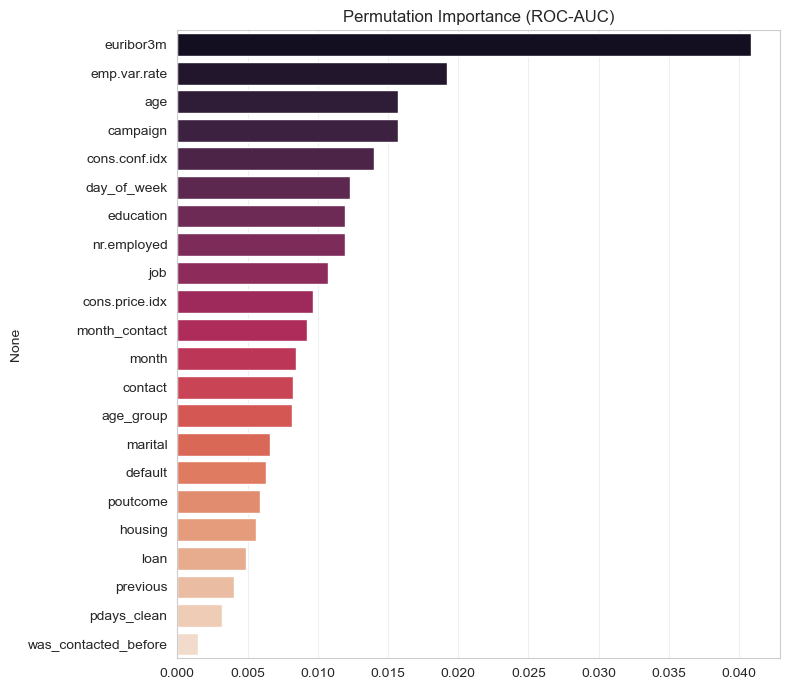

euribor3m               0.040869
emp.var.rate            0.019182
age                     0.015748
campaign                0.015729
cons.conf.idx           0.013997
day_of_week             0.012265
education               0.011952
nr.employed             0.011912
job                     0.010705
cons.price.idx          0.009635
month_contact           0.009255
month                   0.008467
contact                 0.008269
age_group               0.008139
marital                 0.006578
default                 0.006307
poutcome                0.005858
housing                 0.005620
loan                    0.004892
previous                0.004032
pdays_clean             0.003211
was_contacted_before    0.001478
dtype: float64

In [36]:
from sklearn.inspection import permutation_importance

rf_selector = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42,
                                       class_weight='balanced', n_jobs=-1)
rf_selector.fit(x_fs, y_fs)
rf_importance = pd.Series(rf_selector.feature_importances_, index=x_fs.columns).sort_values(ascending=False)

perm_result = permutation_importance(rf_selector, x_fs, y_fs, n_repeats=5,
                                       random_state=42, n_jobs=-1, scoring='roc_auc')
perm_series = pd.Series(perm_result.importances_mean, index=x_fs.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 7))
sns.barplot(x=perm_series.values, y=perm_series.index, palette='rocket')
plt.title('Permutation Importance (ROC-AUC)')
plt.tight_layout()
plt.show()
perm_series

**Feature Selection Summary and Final Decision**

Multiple feature selection techniques were applied to evaluate feature importance from different perspectives. Overall, the results were highly consistent.

Macroeconomic variables (euribor3m, emp.var.rate, nr.employed, cons.price.idx, and cons.conf.idx) consistently ranked among the most important predictors, while previous campaign variables (was_contacted_before, poutcome, previous, and pdays_clean) also showed strong predictive value. Demographic features generally had lower importance.

Although Lasso and RFE suggested removing a few variables, other methods such as Mutual Information, Random Forest, and Permutation Importance indicated that these features still contain useful information. Given the relatively small number of predictors and the ability of tree-based models to handle less informative features, all engineered features were retained for the final modeling stage. This approach preserves potentially valuable information while allowing each algorithm to identify the most relevant predictors during training.

In [42]:
df_feat.to_csv("processed_data.csv", index=False)